# Comprensión y análisis exploratorio de datos (EDA)

**Proyecto:** Predicción de comportamiento de pago de créditos (PIM5)

Dataset histórico de créditos otorgados por una entidad financiera. La variable
objetivo es `Pago_atiempo` (1 = el cliente pagó a tiempo, 0 = no pagó a tiempo).

Este notebook cubre:
1. Exploración inicial de datos (descripción general, caracterización, nulos, tipos)
2. Análisis univariable
3. Análisis bivariable (vs. variable objetivo)
4. Análisis multivariable
5. Reglas de validación y transformaciones sugeridas para etapas posteriores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
DATA_PATH = Path('..') / 'Base_de_datos.csv'
df = pd.read_csv(DATA_PATH)
print(f'Registros: {df.shape[0]}  |  Columnas: {df.shape[1]}')
df.head()

Registros: 10763  |  Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración inicial de datos

### 1.1 Descripción general y caracterización de variables

Antes de tipar o transformar nada, se describe cada variable: qué representa y a
qué tipo estadístico corresponde (numérica continua/discreta, categórica nominal,
categórica ordinal, dicotómica o politómica).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

**Caracterización de variables:**

| Variable | Tipo | Naturaleza |
|---|---|---|
| `tipo_credito` | Categórica nominal (codificada como entero) | Politómica (6 categorías) |
| `fecha_prestamo` | Fecha/hora | — |
| `capital_prestado` | Numérica continua | — |
| `plazo_meses` | Numérica discreta / ordinal | Politómica (18 valores) |
| `edad_cliente` | Numérica discreta | — |
| `tipo_laboral` | Categórica nominal | Dicotómica (Empleado / Independiente) |
| `salario_cliente` | Numérica continua | — |
| `total_otros_prestamos` | Numérica continua | — |
| `cuota_pactada` | Numérica continua | — |
| `puntaje` | Numérica continua | — |
| `puntaje_datacredito` | Numérica continua | — |
| `cant_creditosvigentes` | Numérica discreta | — |
| `huella_consulta` | Numérica discreta | — |
| `saldo_mora` | Numérica continua | — |
| `saldo_total` | Numérica continua | — |
| `saldo_principal` | Numérica continua | — |
| `saldo_mora_codeudor` | Numérica continua | — |
| `creditos_sectorFinanciero` | Numérica discreta | — |
| `creditos_sectorCooperativo` | Numérica discreta | — |
| `creditos_sectorReal` | Numérica discreta | — |
| `promedio_ingresos_datacredito` | Numérica continua | — |
| `tendencia_ingresos` | Categórica nominal (**con anomalía, ver 1.3**) | Politómica (Estable / Creciente / Decreciente) |
| `Pago_atiempo` | Categórica **variable objetivo** | Dicotómica (0 / 1) |

### 1.2 Revisión de nulos

In [4]:
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct}).query('nulos > 0').sort_values('nulos', ascending=False)

,nulos,porcentaje
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


**Observaciones:**
- `tendencia_ingresos` y `promedio_ingresos_datacredito` concentran la mayor
  cantidad de nulos (~27%), y coinciden bastante en las mismas filas — sugiere que
  ambas provienen de la misma fuente externa (consulta a central de riesgo) que
  no siempre responde.
- `saldo_mora_codeudor`, `saldo_principal`, `saldo_total`, `saldo_mora` tienen
  nulos menores, probablemente créditos sin codeudor o sin saldo registrado aún.
- No se detectan nulos representados con strings tipo `'NA'`, `'-'` o `'?'`: los
  nulos ya están unificados como `NaN` de pandas, no hace falta reemplazo adicional.

In [5]:
df.duplicated().sum()

np.int64(0)

**No hay filas duplicadas.**

### 1.3 Anomalía detectada en `tendencia_ingresos`

Esta columna debería ser categórica (`Estable`, `Creciente`, `Decreciente`, o nulo),
pero contiene valores numéricos "colados" — probablemente un error de carga o de
mapeo de columnas en el origen de datos.

In [6]:
categorias_validas = {'Estable', 'Creciente', 'Decreciente'}
es_valor_raro = ~df['tendencia_ingresos'].isin(categorias_validas) & df['tendencia_ingresos'].notna()
print(f'Filas con valor no válido en tendencia_ingresos: {es_valor_raro.sum()}')
df.loc[es_valor_raro, ['tendencia_ingresos', 'promedio_ingresos_datacredito']].head(10)

Filas con valor no válido en tendencia_ingresos: 58


,tendencia_ingresos,promedio_ingresos_datacredito
157,8315,939017.0
168,0,1200000.0
440,158042,28878675.0
486,3978,1562215.0
705,9147,1000000.0
1185,8315,977131.0
1188,168750,2550000.0
1898,-28589,5425531.0
2027,8315,916148.0
2038,1000000,917014.0


**Regla de validación propuesta:** cualquier valor de `tendencia_ingresos` fuera
de `{Estable, Creciente, Decreciente, NaN}` debe tratarse como dato corrupto y
convertirse a nulo, no descartarse la fila. Se deja documentado para la etapa de
limpieza/feature engineering; **no se modifica el dataset en este notebook**, que
es puramente exploratorio.

### 1.4 Eliminación de variables irrelevantes

`fecha_prestamo` no aporta como variable predictiva en su forma cruda (es un
timestamp con altísima cardinalidad, casi todos los valores únicos), pero sí puede
ser útil para derivar variables (mes, día de la semana, antigüedad). Se conserva
en el dataset para el análisis pero se marca para transformación en la etapa de
feature engineering en lugar de eliminarla directamente.

In [7]:
print('Valores únicos en fecha_prestamo:', df['fecha_prestamo'].nunique(), 'sobre', len(df), 'filas')
print('Rango de fechas:', df['fecha_prestamo'].min(), '→', df['fecha_prestamo'].max())

Valores únicos en fecha_prestamo: 10758 sobre 10763 filas
Rango de fechas: 2024-11-26 09:17:04 → 2026-04-26 18:43:52


### 1.5 Corrección de tipos de datos

`fecha_prestamo` llega como texto; se convierte a `datetime`. El resto de los
tipos numéricos y categóricos ya vienen razonablemente bien tipados por pandas al
leer el `.csv`.

In [8]:
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
df.dtypes

tipo_credito                           category
fecha_prestamo                   datetime64[us]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

## 2. Exploración de datos y descripción (EDA)

### 2.1 Análisis univariable — variables numéricas

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Pago_atiempo')
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01
huella_consulta,10763.0,4.228561e+00,3.064683e+00,0.00000,2.000000e+00,4.000000e+00,6.000000e+00,2.900000e+01


**Lectura rápida de tendencia central y dispersión:**
- `salario_cliente` y `total_otros_prestamos` muestran una dispersión extrema
  (desvío estándar muchísimo mayor que la mediana esperable): hay valores
  atípicos de varios órdenes de magnitud por encima del resto (ver celda
  siguiente). Esto **no se trata como dato inválido sin más**: puede tratarse de
  clientes de alto patrimonio, pero amerita una regla de validación / winsorización
  antes de modelar.
- `edad_cliente`, `plazo_meses`, `puntaje` y `puntaje_datacredito` tienen rangos
  y dispersión razonables para su naturaleza.

In [10]:
df[['salario_cliente', 'total_otros_prestamos']].sort_values('salario_cliente', ascending=False).head(10)

,salario_cliente,total_otros_prestamos
5735,22000000000,10000000
2866,16991100000,200000
7014,13258352050,4316463703
7043,12450806583,6787675263
7041,8252584000,3147612000
7070,7170914725,4974345404
7053,4857353453,1108557358
7116,4663274549,934303642
7110,4067140000,3918433000
7058,3979311000,3758729000


**Regla de validación propuesta:** definir un techo razonable para
`salario_cliente` (por ejemplo, un percentil 99 o un tope de negocio conocido, ej.
salarios > 500 millones son casi con certeza error de captura) y tratar los
valores por encima como outliers a revisar, no a imputar automáticamente.

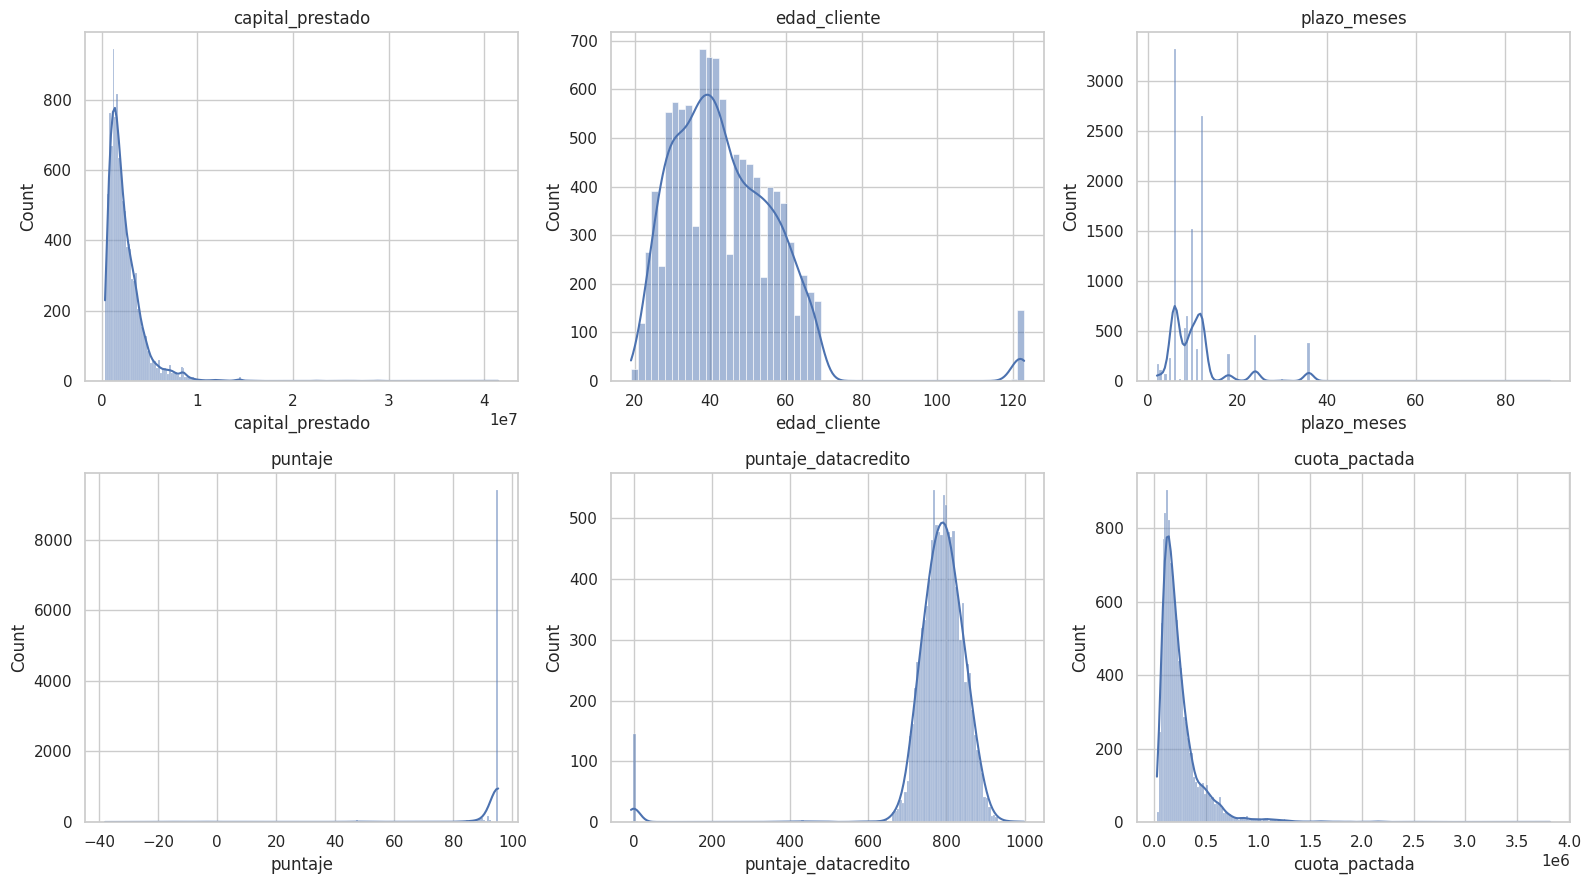

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_hist = ['capital_prestado', 'edad_cliente', 'plazo_meses', 'puntaje', 'puntaje_datacredito', 'cuota_pactada']
for ax, col in zip(axes.flat, cols_hist):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

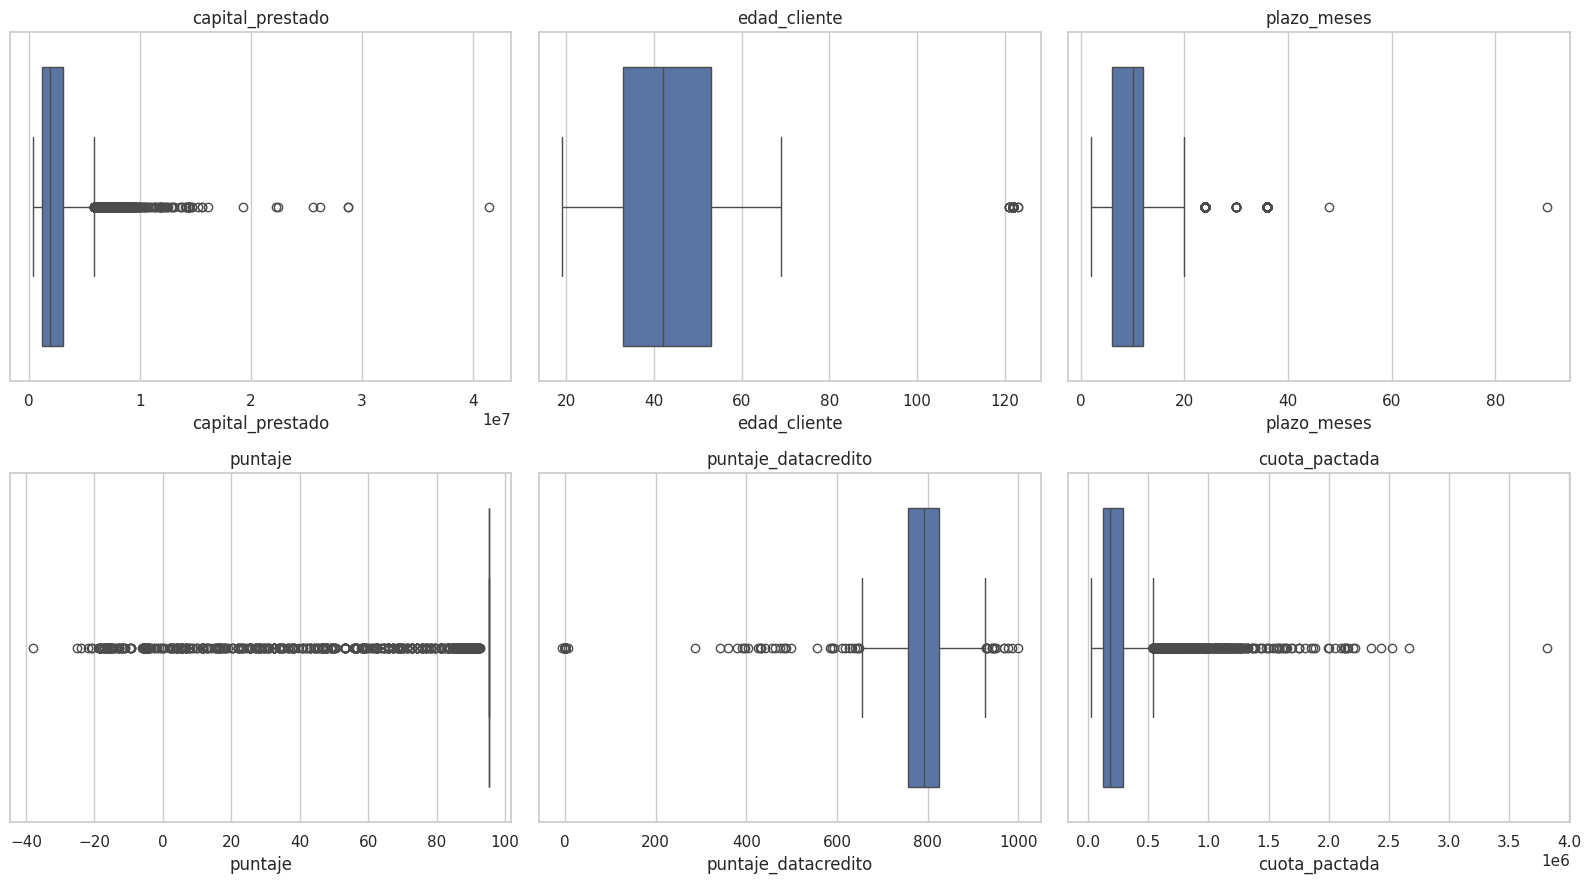

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cols_hist):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [13]:
pd.pivot_table(df, values=['capital_prestado', 'puntaje_datacredito'],
               index='tipo_credito', aggfunc=['mean', 'median', 'count'])

mean                               median                                count                    
             capital_prestado puntaje_datacredito capital_prestado puntaje_datacredito capital_prestado puntaje_datacredito
tipo_credito                                                                                                               
4                2.414644e+06          790.076953        1929896.4               789.0             7747                7745
6                2.860483e+06          743.523810        2309859.6               759.0               21                  21
7                8.117212e+06          749.000000        8117211.6               749.0                2                   2
9                2.445491e+06          755.689067        1892546.4               797.0             2876                2872
10               3.292477e+06          789.362069        2328660.0               791.5              116                 116
68               2.822824e+06          804.000000        2822823.6               804.0                1                   1

### 2.2 Análisis univariable — variables categóricas

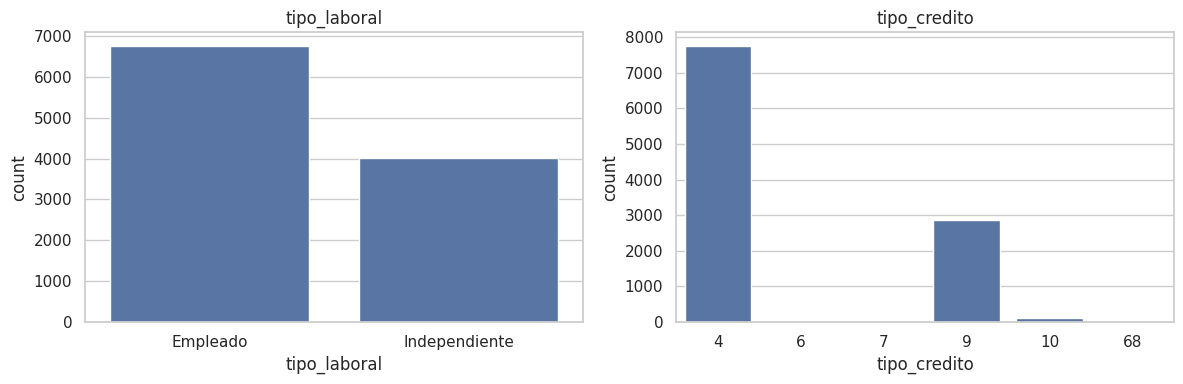

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='tipo_laboral', ax=axes[0])
axes[0].set_title('tipo_laboral')
sns.countplot(data=df, x='tipo_credito', ax=axes[1])
axes[1].set_title('tipo_credito')
plt.tight_layout()
plt.show()

In [15]:
df['tipo_laboral'].value_counts(normalize=True).round(3)

tipo_laboral
Empleado         0.628
Independiente    0.372
Name: proportion, dtype: float64

In [16]:
df['tendencia_ingresos'].where(df['tendencia_ingresos'].isin(categorias_validas)).value_counts(normalize=True).round(3)

tendencia_ingresos
Creciente      0.681
Decreciente    0.166
Estable        0.153
Name: proportion, dtype: float64

In [17]:
pd.pivot_table(df, values='capital_prestado', index='tipo_laboral', aggfunc=['mean', 'count'])

,mean,count
,capital_prestado,capital_prestado
tipo_laboral,,
Empleado,2.394980e+06,6754
Independiente,2.500582e+06,4009


**Estadística descriptiva y forma de distribución (numéricas):**
`capital_prestado`, `salario_cliente`, `total_otros_prestamos`, `cuota_pactada` y
los saldos muestran asimetría positiva marcada (cola larga a la derecha, típico de
variables monetarias) — se calcula abajo con skewness y kurtosis.

In [18]:
skew_kurt = pd.DataFrame({
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurt()
}).sort_values('skewness', ascending=False)
skew_kurt

,skewness,kurtosis
saldo_mora_codeudor,94.971504,9279.824860
salario_cliente,43.776664,2211.230120
saldo_mora,40.568483,1845.712807
total_otros_prestamos,38.463886,1719.280871
saldo_total,20.197674,789.166702
saldo_principal,5.050172,51.063839
promedio_ingresos_datacredito,4.280151,32.770749
creditos_sectorCooperativo,4.218667,29.351455
cuota_pactada,3.793301,26.650757
capital_prestado,3.723884,35.318092


**Variables objetivo (`Pago_atiempo`):** fuertemente desbalanceada.

In [19]:
df['Pago_atiempo'].value_counts(normalize=True).round(4)

Pago_atiempo
1    0.9525
0    0.0475
Name: proportion, dtype: float64

Solo ~4.7% de los créditos no se pagaron a tiempo. **Esto es un hallazgo clave
para el próximo avance**: cualquier modelo de clasificación deberá manejar este
desbalanceo (class_weight, resampling, métricas como PR-AUC/recall en vez de
accuracy).

### 2.3 Análisis bivariable (vs. `Pago_atiempo`)

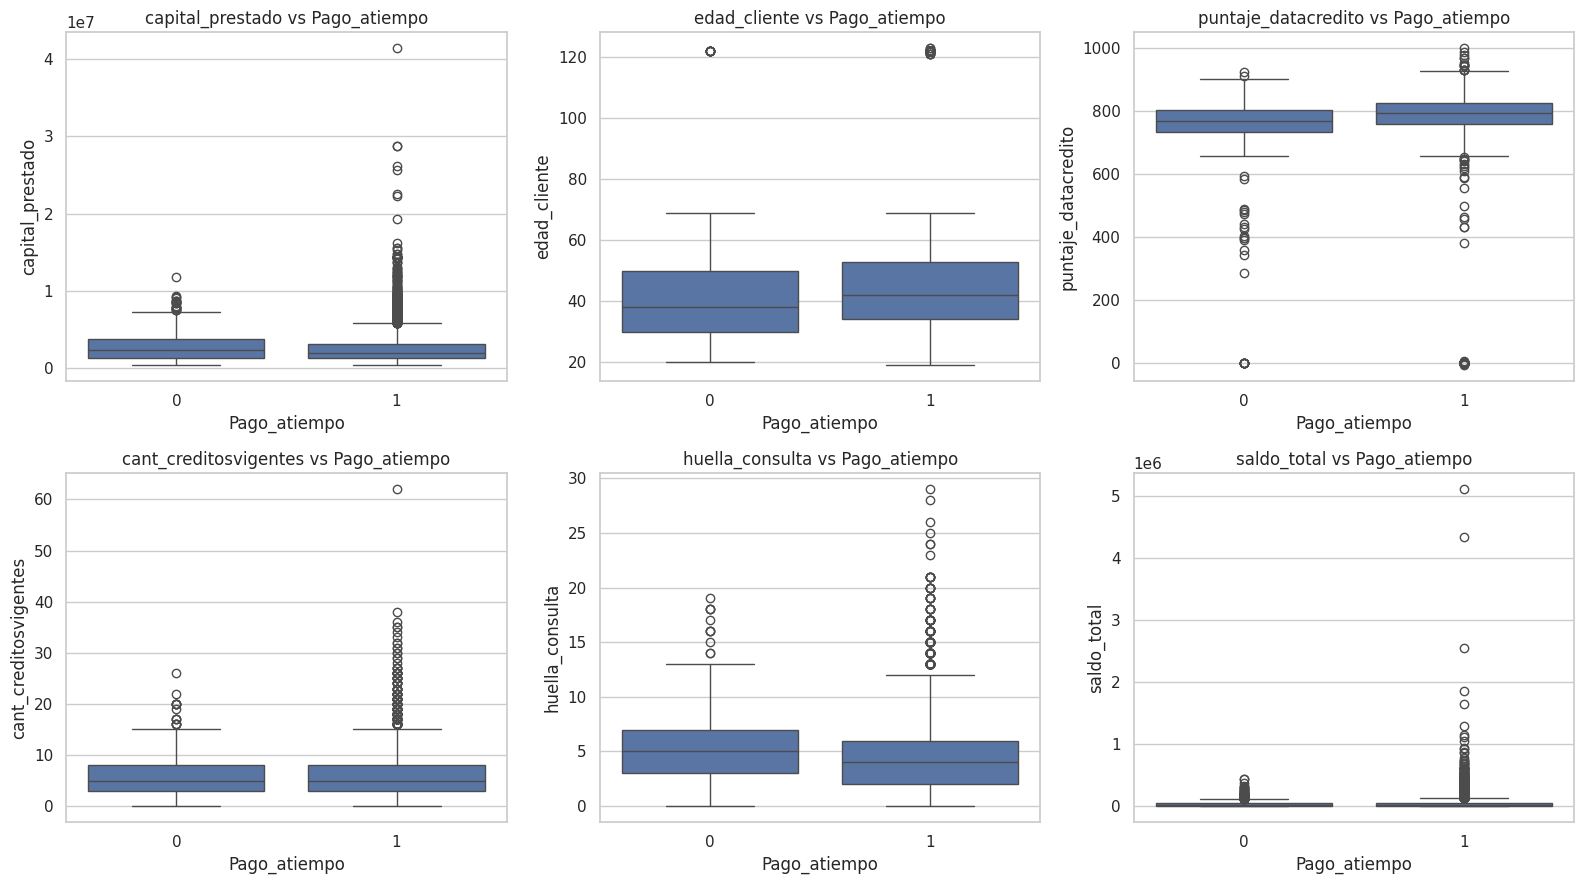

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols_bivar = ['capital_prestado', 'edad_cliente', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_total']
for ax, col in zip(axes.flat, cols_bivar):
    sns.boxplot(data=df, x='Pago_atiempo', y=col, ax=ax)
    ax.set_title(f'{col} vs Pago_atiempo')
plt.tight_layout()
plt.show()

In [21]:
pd.pivot_table(df, values=['puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta'],
               index='Pago_atiempo', aggfunc='mean').round(2)

,cant_creditosvigentes,huella_consulta,puntaje_datacredito
Pago_atiempo,,,
0,5.57,5.24,748.88
1,5.73,4.18,782.38


In [22]:
pd.crosstab(df['tipo_laboral'], df['Pago_atiempo'], normalize='index').round(3)

Pago_atiempo,0,1
tipo_laboral,,
Empleado,0.043,0.957
Independiente,0.055,0.945


In [23]:
pd.crosstab(df['tipo_credito'], df['Pago_atiempo'], normalize='index').round(3)

Pago_atiempo,0,1
tipo_credito,,
4,0.047,0.953
6,0.429,0.571
7,0.000,1.000
9,0.047,0.953
10,0.026,0.974
68,0.000,1.000


**Comentarios del análisis bivariable:**
- `puntaje_datacredito` y `cant_creditosvigentes` muestran diferencias visibles
  entre quienes pagaron a tiempo y quienes no — buenas candidatas como variables
  predictivas fuertes.
- `huella_consulta` (cantidad de consultas recientes a central de riesgo) tiende a
  ser mayor en el grupo que no pagó a tiempo, consistente con la intuición de
  negocio (más consultas → cliente buscando crédito activamente / posible estrés
  financiero).
- `tipo_laboral` y `tipo_credito` muestran diferencias moderadas en la tasa de
  pago a tiempo entre categorías — a confirmar con el modelo si son relevantes
  tras controlar por las demás variables.

### 2.4 Análisis multivariable

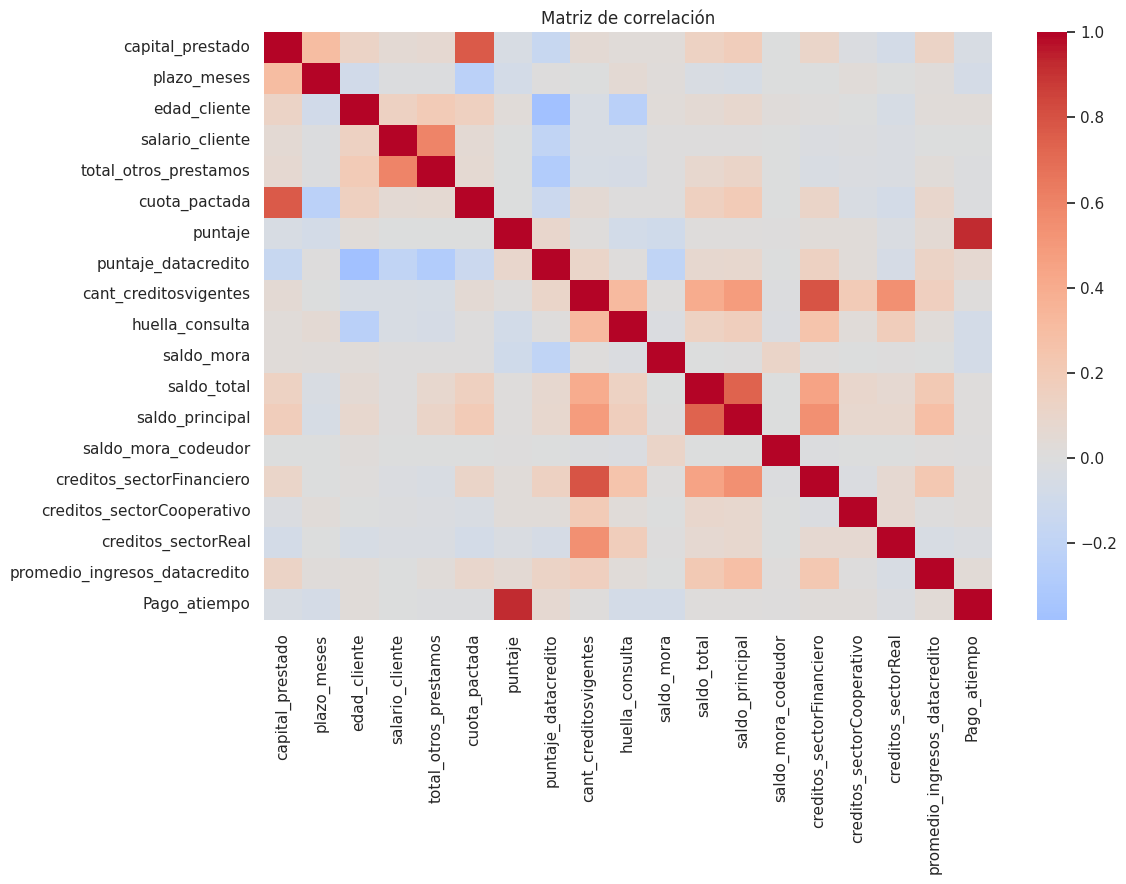

In [24]:
corr = df[num_cols + ['Pago_atiempo']].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [25]:
corr['Pago_atiempo'].sort_values(ascending=False)

Pago_atiempo                     1.000000
puntaje                          0.923134
puntaje_datacredito              0.067882
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
salario_cliente                 -0.003981
total_otros_prestamos           -0.010041
cuota_pactada                   -0.011814
creditos_sectorReal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: Pago_atiempo, dtype: float64

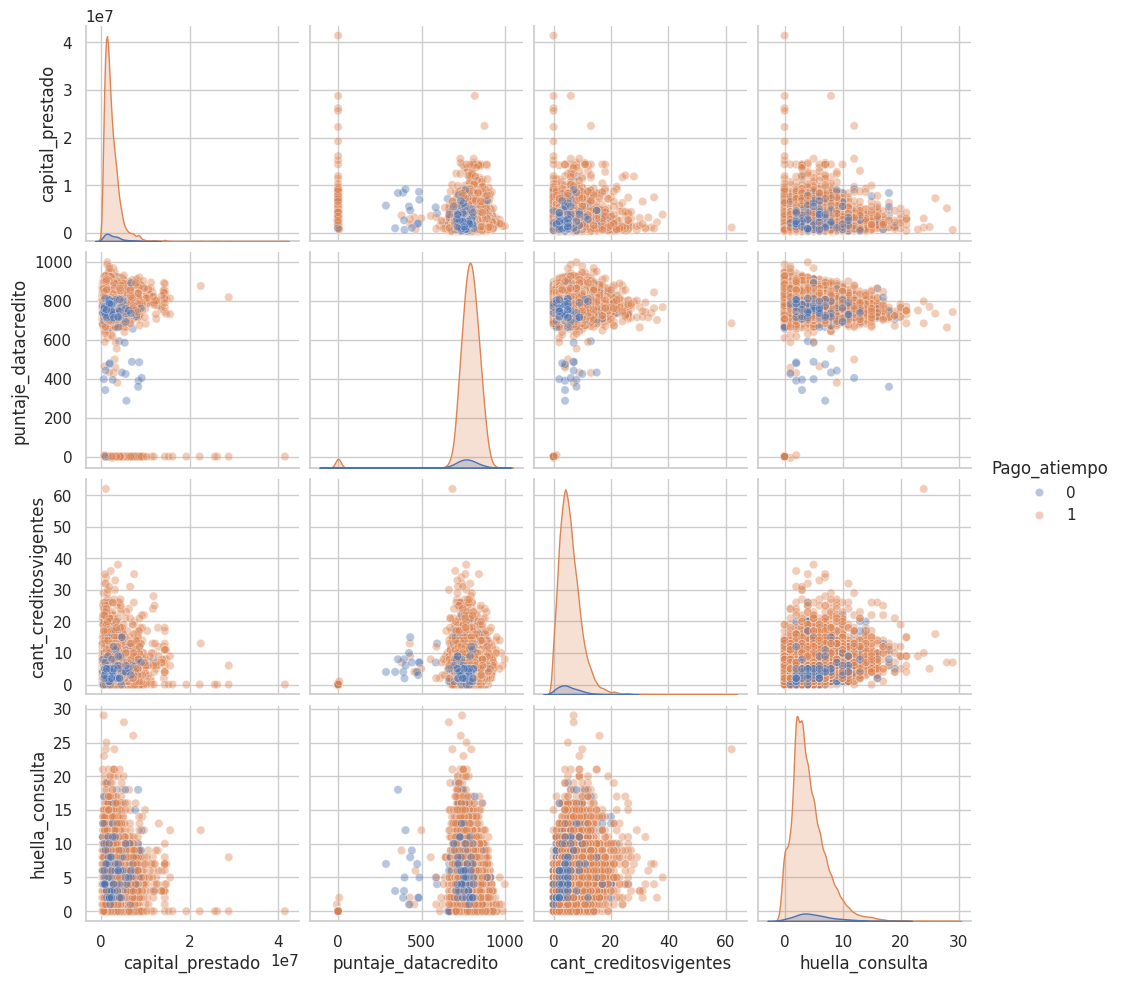

In [26]:
cols_pair = ['capital_prestado', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'Pago_atiempo']
sns.pairplot(df[cols_pair].dropna(), hue='Pago_atiempo', plot_kws={'alpha': 0.4})
plt.show()

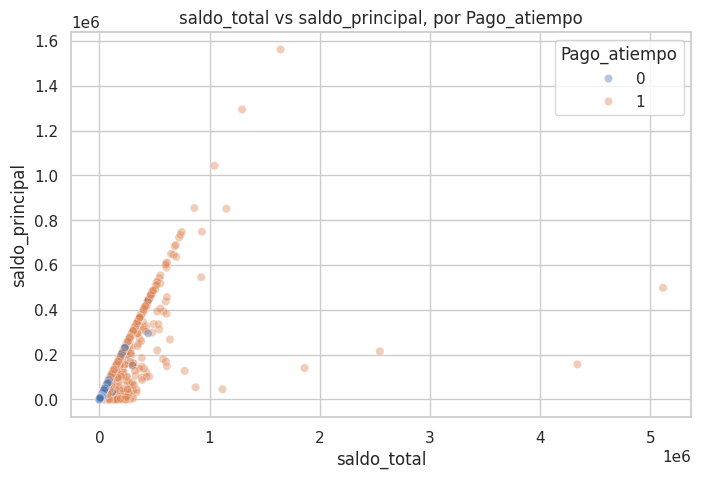

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='saldo_total', y='saldo_principal', hue='Pago_atiempo', alpha=0.4)
plt.title('saldo_total vs saldo_principal, por Pago_atiempo')
plt.show()

**Comentarios del análisis multivariable:**
- `saldo_total` y `saldo_principal` están altamente correlacionadas entre sí (como
  es esperable, uno compone al otro) — candidatas a **redundancia**: en la etapa
  de feature engineering conviene evaluar si conservar ambas aporta información o
  si conviene quedarse con una, o derivar una razón entre ambas.
- La correlación lineal de cada variable individual con `Pago_atiempo` es débil en
  general (esperable dado el fuerte desbalanceo de la clase): esto refuerza que el
  problema probablemente requiera modelos no lineales (árboles / boosting) más que
  regresión lineal simple, y **no** debe interpretarse como que las variables no
  son útiles — la correlación lineal subestima relaciones no lineales.

## 3. Síntesis: reglas de validación, transformaciones y atributos derivados

**Reglas de validación de datos** (para usar en la etapa de ingesta / feature engineering):
- `tendencia_ingresos`: solo son válidos `Estable`, `Creciente`, `Decreciente` o
  nulo; cualquier otro valor se considera dato corrupto.
- `salario_cliente` y `total_otros_prestamos`: definir un techo de negocio
  razonable; valores muy por encima (varios órdenes de magnitud sobre la mediana)
  deben marcarse para revisión, no usarse tal cual.
- `plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`: deben
  ser enteros no negativos (validar rango físicamente posible, ej. edad entre 18 y
  100).
- `Pago_atiempo`: validar que sea estrictamente binaria (0/1), sin nulos, dado que
  es la variable objetivo.

**Transformaciones identificadas para la siguiente etapa:**
- Imputar o marcar como categoría "Desconocido" los nulos de `tendencia_ingresos`
  y `promedio_ingresos_datacredito` (dado que su ausencia parece sistemática, no
  aleatoria).
- Tratar outliers de `salario_cliente` / `total_otros_prestamos` (winsorización o
  transformación logarítmica, dada la fuerte asimetría positiva).
- Codificar `tipo_credito` y `tipo_laboral` como variables categóricas (one-hot o
  target encoding, a definir en feature engineering).
- Evaluar transformación logarítmica para variables monetarias con alta asimetría
  (`capital_prestado`, `cuota_pactada`, `saldo_total`, `saldo_principal`).

**Atributos derivados potencialmente útiles:**
- `antiguedad_credito_dias` o `mes_prestamo` / `dia_semana_prestamo` a partir de
  `fecha_prestamo`.
- `relacion_cuota_salario` = `cuota_pactada` / `salario_cliente` (capacidad de pago
  relativa).
- `relacion_deuda_salario` = `total_otros_prestamos` / `salario_cliente`
  (nivel de endeudamiento).
- `saldo_mora_total` = suma de `saldo_mora` + `saldo_mora_codeudor`.
- `total_creditos_sector` = suma de `creditos_sectorFinanciero` +
  `creditos_sectorCooperativo` + `creditos_sectorReal` (exposición crediticia total).

Este notebook es exploratorio: **no se sobrescribe `Base_de_datos.csv`**. Las
transformaciones aquí identificadas se implementarán en `ft_engineering.py` en el
próximo avance.